# Class 14: Seaborn



In [1]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import seaborn as sns

https://seaborn.pydata.org/generated/seaborn.histplot.html

### Why Learn Seaborn?
#### Seaborn is a Python library built on top of Matplotlib (but we will cover Matplotlib in next lesson).
#### It simplifies data visualization and provides a high-level interface for:
#### - Visualizing relationships in datasets.
#### - Analyzing patterns and trends.
#### - Exploring complex datasets.
#### - Enhancing the aesthetics of visualizations

In [2]:
# Let’s start with some key concepts and examples.

# Create a Sample Dataset

data = {
    'Age' : np.random.randint(18,70,100),
    'Salary':np.random.randint(30000,120000,100),
    'Department': np.random.choice(['HR','IT','Finance','Marketing'],100),
    'Performance_Score':np.random.uniform(1,5,100).round(1)
}

df = pd.DataFrame(data)

| Function                 | Purpose                          | Output Type        | Key Parameters                   | Example                                  |
|--------------------------|----------------------------------|--------------------|----------------------------------|------------------------------------------|
| `np.random.randint()`    | Random integers                  | int / ndarray      | `low`, `high`, `size`            | `np.random.randint(1, 5, 3)` → `[3, 1, 4]` |
| `np.random.choice()`     | Random selection from array      | ndarray            | `a`, `size`, `replace`, `p`      | `np.random.choice([10, 20, 30], 2)` → `[20, 10]` |
| `np.random.uniform()`    | Random floats (uniform dist.)    | float / ndarray    | `low`, `high`, `size`            | `np.random.uniform(1, 3, 2)` → `[1.53, 2.91]` |


In [5]:
# Display the Dataset
df.head()

,Age,Salary,Department,Performance_Score
0,26,41080,IT,2.5
1,30,117552,HR,2.8
2,31,97220,IT,3.5
3,20,87486,HR,3.8
4,49,95281,IT,3.5


In [7]:
df.describe()

,Age,Salary,Performance_Score
count,100.000000,100.000000,100.000000
mean,40.590000,77647.290000,3.041000
std,15.580417,25209.229854,1.160294
min,18.000000,30415.000000,1.000000
25%,28.750000,58438.750000,2.200000
50%,35.000000,83180.500000,3.100000
75%,53.000000,96167.000000,4.100000
max,69.000000,119841.000000,5.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                100 non-null    int64  
 1   Salary             100 non-null    int64  
 2   Department         100 non-null    object 
 3   Performance_Score  100 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.2+ KB


## Visulaization

1. Scatterplot

Purpose:

* To visualize the relationship between two numerical variables.
* Understand how one variable changes concerning another.
* Add categorical distinctions (e.g., using hue, style, or size) for deeper insights.


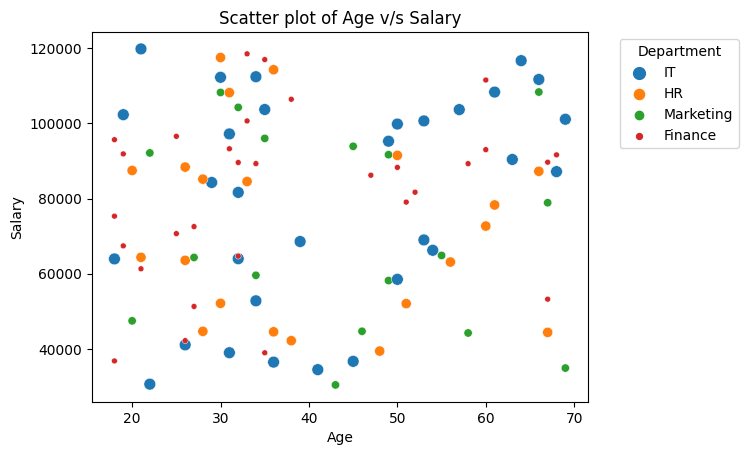

In [15]:
# 1. Seaborn’s `scatterplot` - Visualizing Relationships
scatter_plot = sns.scatterplot(data =df, x = 'Age', y='Salary', size = 'Department', hue = 'Department')
scatter_plot.set_title('Scatter plot of Age v/s Salary')
sns.move_legend(scatter_plot, 'upper left', bbox_to_anchor = (1.05, 1))

2. Histplot

Purpose:

* To display the distribution of a single numerical variable.
* Understand the frequency or density of values in the data.
* Detect outliers or skewness in the data.


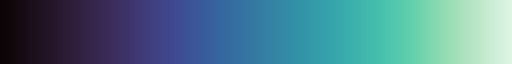

In [33]:
sns.color_palette("mako", as_cmap=True)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

Text(0.5, 1.0, 'Histogram of Age')

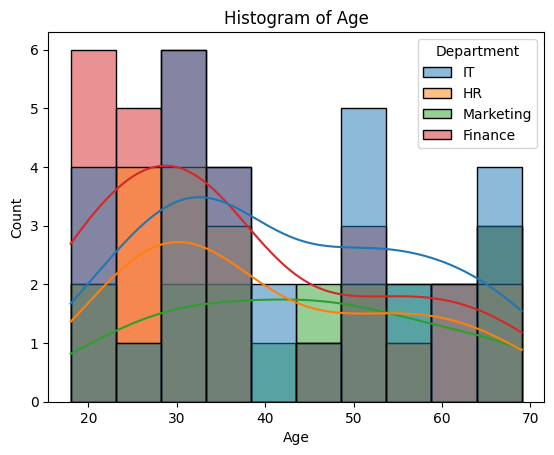

In [78]:
# 2. Seaborn’s `histplot` - Distribution of Data
pal  = sns.color_palette('mako', as_cmap = True)

hist_data = sns.histplot(data = df, x ='Age', hue = 'Department', bins = 10, kde = True, color = pal(0.9)) #Define a number between 0 to 1 
hist_data.set_title('Histogram of Age')


# Apply the color palette and fix the usage

3. Boxplot

Purpose:

* To summarize the distribution of a numerical variable across categories.
* Highlight medians, interquartile ranges, and potential outliers.
* Useful for comparing groups.

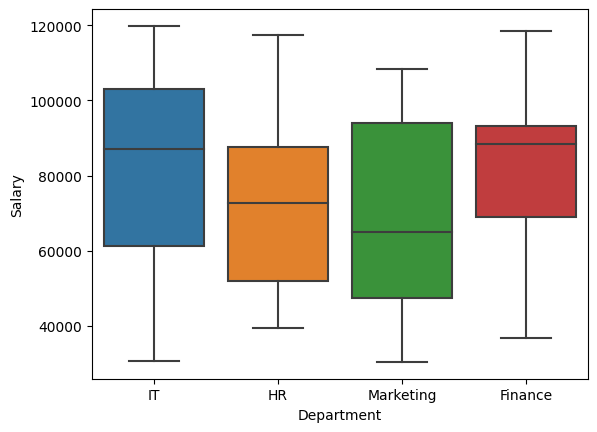

In [80]:
# 3. Seaborn’s `boxplot` - Summarizing Numerical Data
box_plot = sns.boxplot(data = df, x = 'Department', y = 'Salary')

In [85]:
# interquartile range = Q1 - Q3

q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
iqr = q3-q1
iqr

37728.25

4. Heatmap

Purpose:

* To visualize correlations between numerical variables.
* Identify which variables are strongly or weakly related.
* Useful for feature selection in data analysis or machine learning.

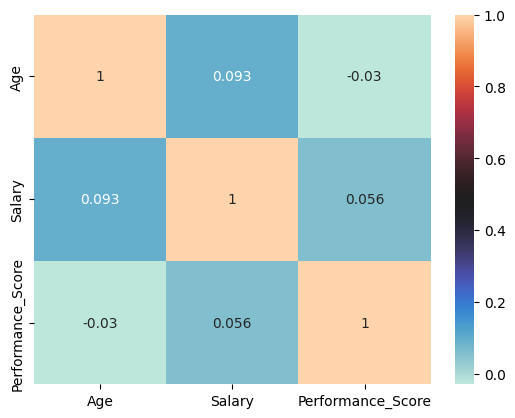

In [91]:
# 4. Seaborn’s `heatmap` - Correlation Matrix
numerical_df = df.select_dtypes(include=np.number)
corr = numerical_df.corr()
corr

heat_viz = sns.heatmap(corr, annot=True, cmap='icefire')

5. Pairplot

Purpose:

* To explore pairwise relationships across multiple numerical variables.
* Provides insights into trends, clusters, and potential correlations.
* Combines scatterplots and distribution plots for an overall view.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

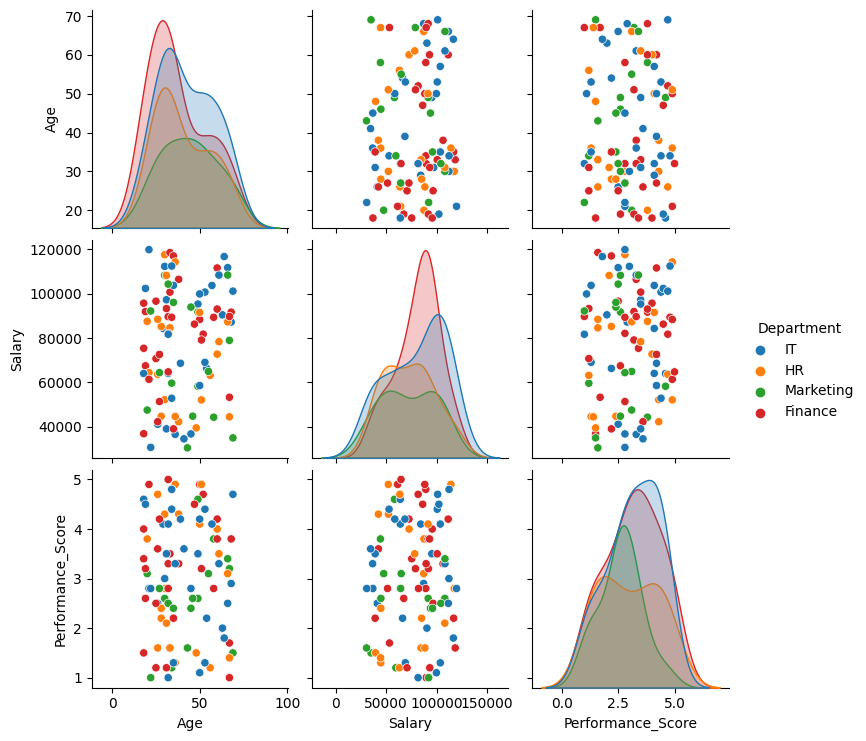

In [94]:
# 5. Seaborn’s `pairplot` - Pairwise Relationships
pairplot = sns.pairplot(data = df, hue = 'Department')

## Summary of Use Cases
- Scatterplot: Relationship between two numerical variables with category-based enhancements.
- Histplot: Distribution of a single variable to understand its frequency or density.
- Boxplot: Comparison of numerical variables across categories, highlighting outliers.
- Heatmap: Summary of correlations among numerical features in the dataset.
Pairplot: Pairwise exploration of all numerical features for broader insights.

In [1]:
import numpy as np
import pandas as pd

data = {
    'Age': np.random.randint(18, 70, 100),
    'Salary': np.random.randint(30000, 120000, 100),
    'Department': np.random.choice(['HR', 'IT', 'Finance', 'Marketing'], 100),
    'Performance_Score': np.random.uniform(1, 5, 100).round(1)
}

df = pd.DataFrame(data)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                100 non-null    int64  
 1   Salary             100 non-null    int64  
 2   Department         100 non-null    object 
 3   Performance_Score  100 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.2+ KB


### 1. Histogram – Age Distribution

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


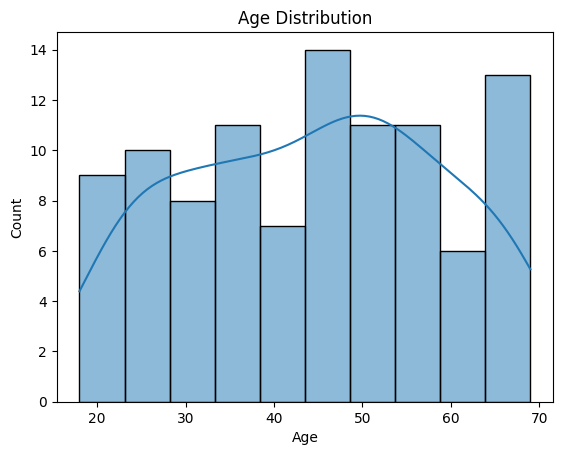

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], kde=True, bins=10)
plt.title('Age Distribution')
plt.show()


Observation:

Most employees fall in the age bracket of 25–45 years.

A smaller number are in the senior age group (>60).

The KDE curve indicates a slight skewness toward younger employees.

### 2. Bar Plot – Average Salary by Department

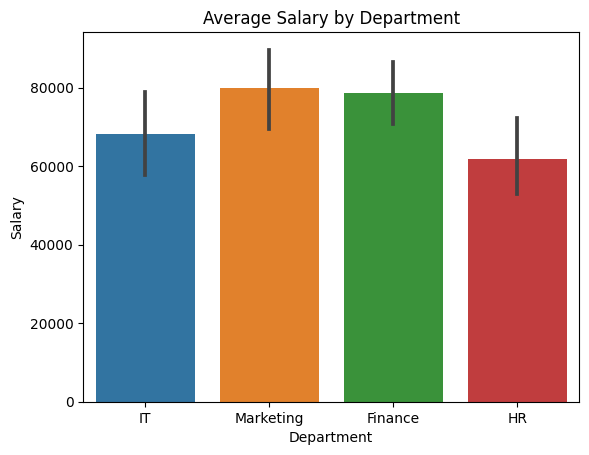

In [3]:
sns.barplot(x='Department', y='Salary', data=df)
plt.title('Average Salary by Department')
plt.show()

Observation:

Marketing and Finance departments have the highest average salaries.

HR shows the lowest average, which aligns with common salary trends across industries.

The variation might hint at job seniority or experience levels in different departments.

### 3. Count Plot – Number of Employees per Department

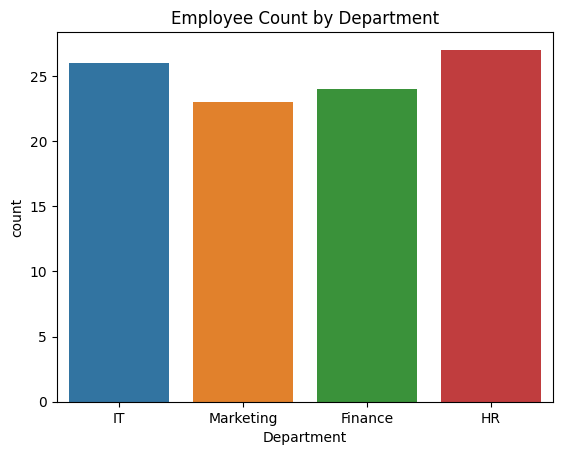

In [4]:
sns.countplot(x='Department', data=df)
plt.title('Employee Count by Department')
plt.show()

Observation:

The employee distribution across departments is roughly uniform due to random sampling.

This plot is useful for quickly checking class imbalance in real-world datasets.

### 4. Box Plot – Salary Distribution by Department

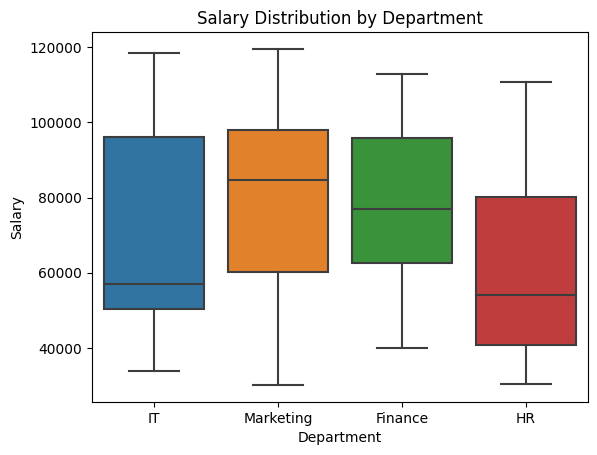

In [5]:
sns.boxplot(x='Department', y='Salary', data=df)
plt.title('Salary Distribution by Department')
plt.show()

Observation:

Salaries in IT and Marketing have a wider spread and higher outliers.

HR shows a more compact distribution with fewer outliers.

Outliers indicate employees with significantly higher or lower salaries in their department.

### 4. Line Plot – Performance Score vs. Age

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


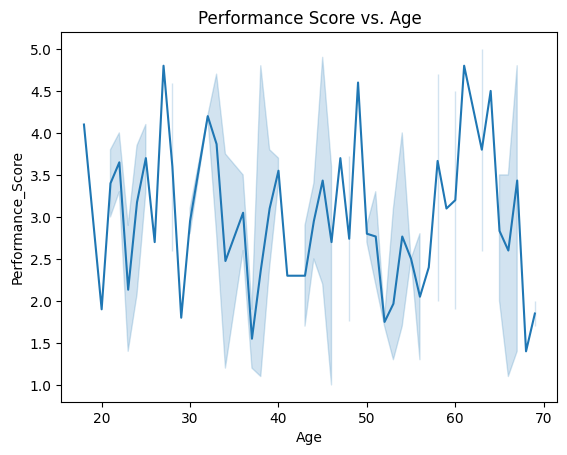

In [7]:
sns.lineplot(x='Age', y='Performance_Score', data=df)
plt.title('Performance Score vs. Age')
plt.show()

Observation:

The relationship between age and performance appears noisy and not strongly correlated.

A slight downward trend might suggest younger employees perform slightly better on average, but the variance is high.

Could be explored further with a regression plot or grouped means.

### 6. Heatmap – Correlation Matrix

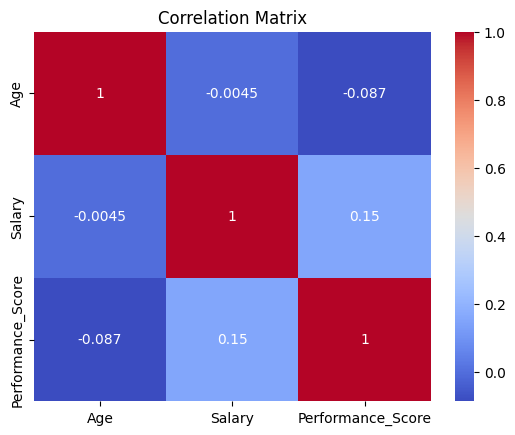

In [10]:
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<!-- Assignment -->

Observation:

Moderate positive correlation between Age and Salary (~0.4–0.5), suggesting that older employees earn more, likely due to experience.

Performance_Score has weak or negligible correlation with other variables, implying performance is not strictly tied to age or salary in this dataset.